In [11]:
import pandas as pd
import numpy as np

# 1. Load the data
# We use '../data/train.csv' because the notebook is inside the /notebooks folder
df = pd.read_csv('../data/train.csv')

print("Original shape:", df.shape)
print("\nMissing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

# 2. Missing Value Handling
# Impute Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin due to high missing percentage
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# 3. Outlier Handling (Capping at 95th percentile)
fare_95 = df['Fare'].quantile(0.95)
age_95 = df['Age'].quantile(0.95)

df['Fare'] = df['Fare'].clip(upper=fare_95)
df['Age'] = df['Age'].clip(upper=age_95)

# 4. Data Consistency
df.drop_duplicates(inplace=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())

# 5. Deliverable: Save cleaned dataset
df.to_csv('../data/train_cleaned.csv', index=False)
print("\nCleaned dataset saved to 'data/train_cleaned.csv'")

Original shape: (891, 12)

Missing values before cleaning:
 Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Cleaned dataset saved to 'data/train_cleaned.csv'


 Part 2: Feature Engineering

 Strategy for Feature Creation:
* [cite_start]**FamilySize**: Calculated as `SibSp + Parch + 1` to represent the total family count[cite: 51].
* [cite_start]**IsAlone**: A binary flag (1 if FamilySize is 1, else 0) to identify solo travelers[cite: 52].
* [cite_start]**Title**: Extracted from the `Name` column to capture social status[cite: 53].
* [cite_start]**Deck**: Extracted from the first letter of the `Cabin` column (handling nulls as 'U' for Unknown)[cite: 54].
* [cite_start]**Age Groups**: Categorized continuous age into 'Child', 'Teen', 'Adult', and 'Senior'[cite: 55].
* [cite_start]**Fare per Person**: Normalized fare by dividing by family size[cite: 56].
* [cite_start]**Log Transformation**: Applied to `Fare` to reduce skewness for better model performance[cite: 64].
* [cite_start]**Categorical Encoding**: Used One-Hot Encoding for nominal features like Sex and Embarked [cite: 57-58].

In [5]:
import pandas as pd
import numpy as np

# 1. Create Derived Features
# FamilySize: SibSp + Parch + 1 [cite: 51]
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: 1 if FamilySize == 1 else 0 [cite: 52]
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Title extraction from Name [cite: 53]
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Deck extraction from Cabin [cite: 54]
# Since we dropped 'Cabin' in Part 1, we check if it exists or use 'U' for Unknown
if 'Cabin' in df.columns:
    df['Deck'] = df['Cabin'].str[0].fillna('U')
else:
    df['Deck'] = 'U'

# Age groups (Child, Teen, Adult, Senior) [cite: 55]
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 60, 120], labels=['Child', 'Teen', 'Adult', 'Senior'])

# Fare per person [cite: 56]
df['Fare_Per_Person'] = df['Fare'] / df['FamilySize']

# 2. Feature Transformations
# Log transform skewed features (Fare) [cite: 64]
df['Fare_Log'] = np.log1p(df['Fare'])

# 3. Categorical Encoding [cite: 57-58]
# One-hot encode nominal features
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup'], drop_first=True)

print("Feature engineering complete. Current shape:", df.shape)

Feature engineering complete. Current shape: (891, 23)


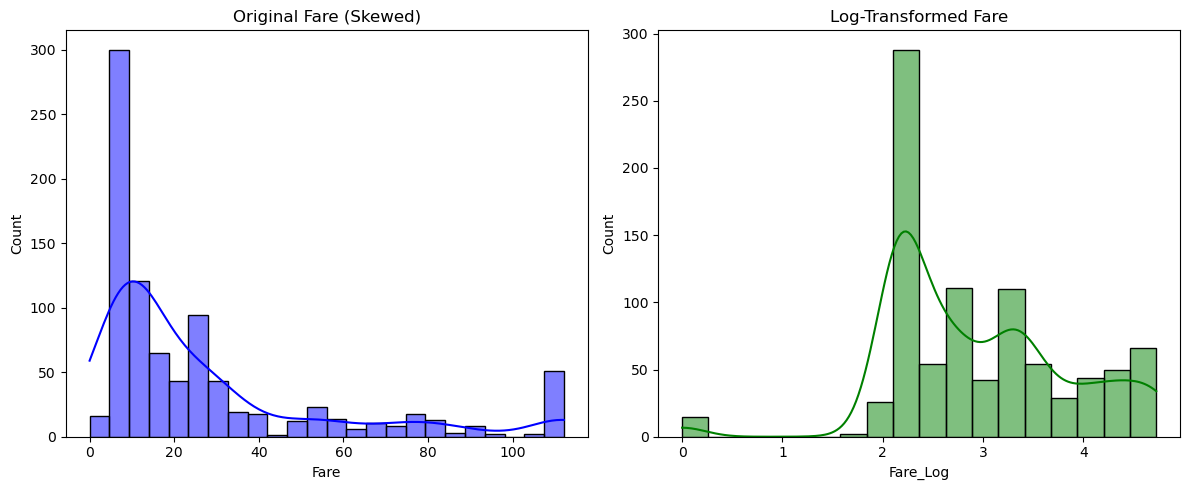

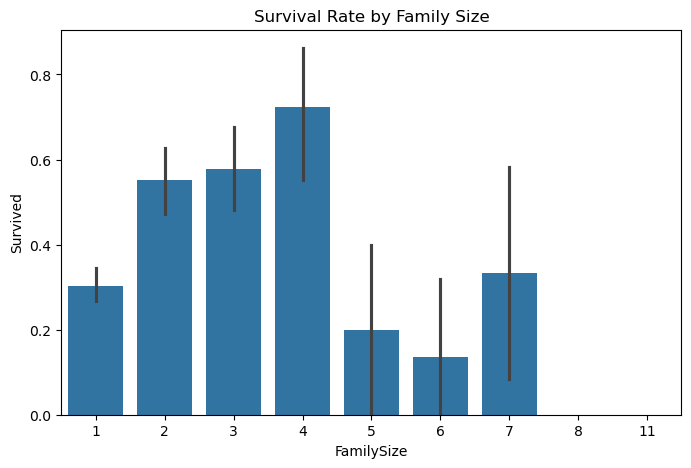

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Visualizing Log Transformation 
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, color='blue')
plt.title('Original Fare (Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(df['Fare_Log'], kde=True, color='green')
plt.title('Log-Transformed Fare')

plt.tight_layout()
plt.show()

# Visualizing Survival by FamilySize 
if 'Survived' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='FamilySize', y='Survived', data=df)
    plt.title('Survival Rate by Family Size')
    plt.show()

Part 3: Feature Selection

 Selection Strategy:
1. **Correlation Analysis**: A heatmap is used to identify features that are too similar (redundant). [cite_start]We want to avoid multicollinearity [cite: 70-71].
2. **Feature Importance (Random Forest)**: We use a tree-based model to rank features. [cite_start]This tells us which variables (like `Title_Mr` or `Fare_Log`) actually contribute most to the model's "decisions" .
3. [cite_start]**Dropping Unnecessary Columns**: We remove identifiers like `PassengerId`, `Name`, and `Ticket` which do not contain predictive patterns [cite: 79-80].

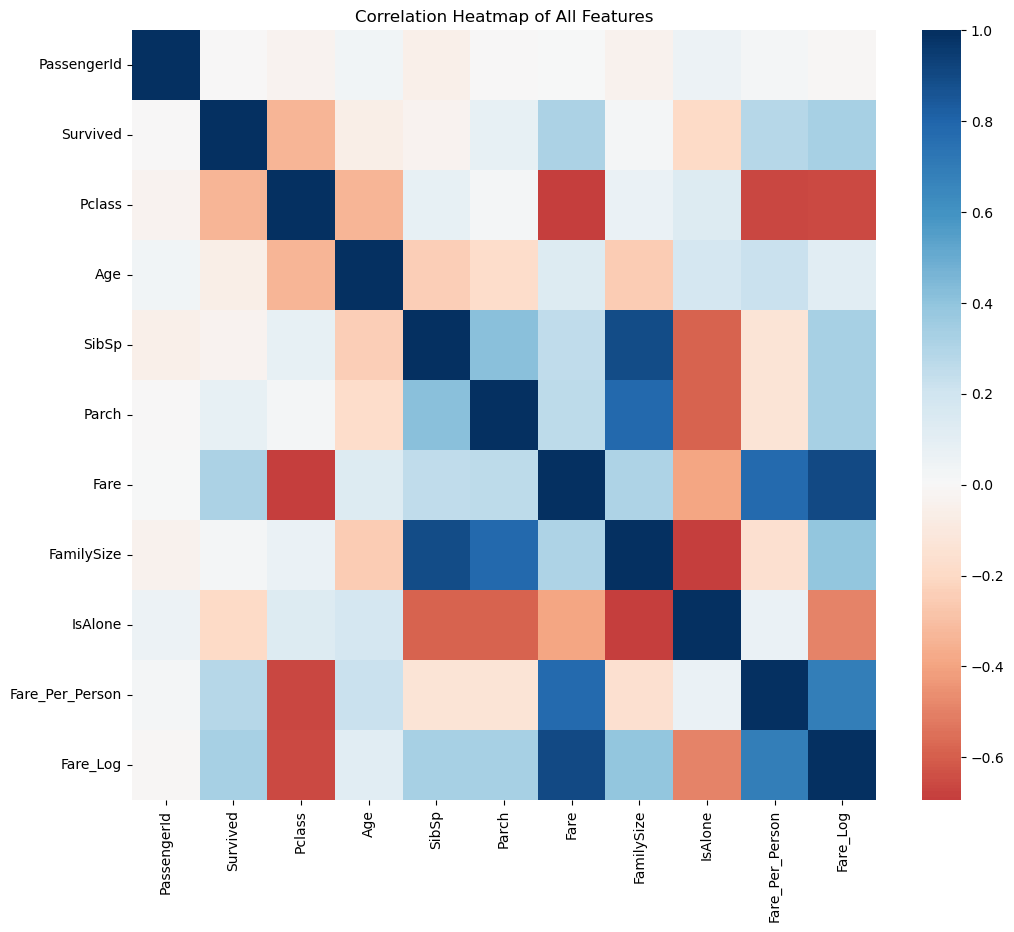

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for the heatmap
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='RdBu', center=0)
plt.title("Correlation Heatmap of All Features")
plt.show()

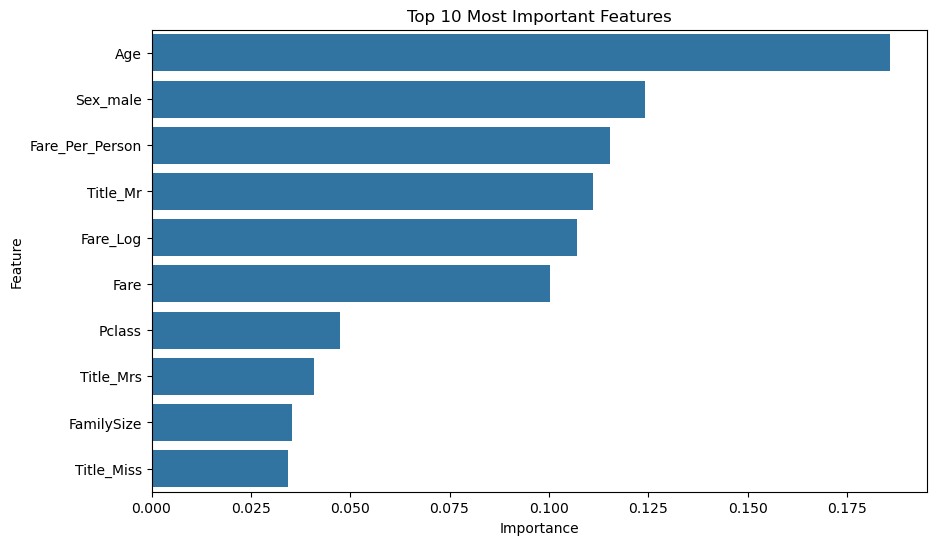

Key Features for the Model:
            Feature  Importance
1               Age    0.185742
9          Sex_male    0.124140
7   Fare_Per_Person    0.115394
13         Title_Mr    0.111167
8          Fare_Log    0.107075
4              Fare    0.100150
0            Pclass    0.047471
14        Title_Mrs    0.040884
5        FamilySize    0.035275
12       Title_Miss    0.034302


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Define target and predictors
# We drop non-numeric/identifier columns before training
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'], errors='ignore')
y = df['Survived']

# Train Random Forest to get importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Create a ranking table
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Visualize the Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Most Important Features")
plt.show()

print("Key Features for the Model:")
print(feature_importance.head(10))

In [10]:
# Select the features we want to keep (Top importances + Survived)
# Usually, we keep everything that isn't a unique ID for the final CSV
cols_to_keep = feature_importance['Feature'].tolist() + ['Survived']
df_final = df[cols_to_keep]

# Save the final deliverable
df_final.to_csv('../data/train_cleaned.csv', index=False)

print("Final dataset saved to data/train_cleaned.csv")
print("Total Features Selected:", len(cols_to_keep) - 1)

Final dataset saved to data/train_cleaned.csv
Total Features Selected: 19
